In [54]:
import json
import pathlib

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import corner

import jax
jax.config.update('jax_enable_x64', True)

import discovery as ds
# import the newly implemented outlier module
from discovery.models.nanograv_single_pulsar_outlier import  *

import numpyro
import numpyro.distributions as dist
import numpyro.infer as infer
from numpyro.infer import init_to_value
import numpyro.handlers as handlers
import sys


In [ ]:
# read in psr file with outlier contamination
psr = ds.Pulsar.read_feather(r"J1643-1224_with_outliers.feather")

In [3]:
from discovery.models.fourierpta import * 
from discovery.models.flowfourierpta import *

In [ ]:
# loading in psrs
npsr = 1
DATA = pathlib.Path(ds.__path__[0] + '/../../data/')
allpsrs = sorted( [ds.Pulsar.read_feather(psrfile) for psrfile in list(DATA.glob("*-[JB]*.feather"))],
    key=lambda psr: len(psr.toas), reverse = True)


In [ ]:
# extracting the noisedict since we will do the outlier analysis
# using fixed WN
psr_name = "J1643-1224"
psr_idx = [p.name for p in allpsrs].index(psr_name)
psr_tmp = allpsrs[psr_idx]
noisedict = psr_tmp.noisedict
psr.noisedict = noisedict

In [6]:
newdict = {'(.*_)?red_noise_coefficients\\(([0-9]*)\\)': [-100, 100]}

In [7]:
rn_components = 30
gw_components = 14
powerlaw = ds.powerlaw
ecorr = True 
tnequad = False

In [148]:
# MAP finder for psr obj. WITH outliers included.
eta0_prime = {"log10_A": -13.5, "gamma": 0.0} 
eta0_regularizer, results = compute_eta_MAP([psr], powerlaw=powerlaw,
                                          priordict=priordict_standard,
                                          eta0_prime=eta0_prime,
                                          n_grid = 10, steps = 3,
                                          zoom = 0.4)


J1643-1224:
eta MAP: gamma=0.78, log10_A=-12.18
informative with ratio = 0.16


In [ ]:
# Fourier model used ONLY for latent space transf below. (the .conditional)
logL_latent = make_fourier_model([psr], psd = ds.partial(ds.powerlaw, **eta0_regularizer[0]),
                               noisedict = psr.noisedict)

In [10]:
# create outlier likelihood using a fixed psd which (conditioned on our regularizer eta_0)
psrl = make_outlier_likelihood(psr, psd = ds.partial(ds.powerlaw, **eta0_regularizer[0]))

In [11]:
Tspan = ds.getspan(psr)
f, df, _ = signals.fourierbasis(psr, rn_components, T=Tspan)
phi0_inv, logdet_phi0 = phi_single_pulsar(eta0_regularizer[0], f, df, ds.powerlaw)

In [12]:
psrl.logL.params

['J1643-1224_3GHz_YUPPI_efac',
 'J1643-1224_3GHz_YUPPI_log10_ecorr',
 'J1643-1224_3GHz_YUPPI_log10_t2equad',
 'J1643-1224_Rcvr1_2_GASP_efac',
 'J1643-1224_Rcvr1_2_GASP_log10_ecorr',
 'J1643-1224_Rcvr1_2_GASP_log10_t2equad',
 'J1643-1224_Rcvr1_2_GUPPI_efac',
 'J1643-1224_Rcvr1_2_GUPPI_log10_ecorr',
 'J1643-1224_Rcvr1_2_GUPPI_log10_t2equad',
 'J1643-1224_Rcvr_800_GASP_efac',
 'J1643-1224_Rcvr_800_GASP_log10_ecorr',
 'J1643-1224_Rcvr_800_GASP_log10_t2equad',
 'J1643-1224_Rcvr_800_GUPPI_efac',
 'J1643-1224_Rcvr_800_GUPPI_log10_ecorr',
 'J1643-1224_Rcvr_800_GUPPI_log10_t2equad',
 'J1643-1224_alpha_scaling(26684)']

In [ ]:
N = psrl.y.size
# ahat0r, L0r will be used for latent space transf
ahat0r, Linv_r = logL_latent[0].conditional({})
L_inv_r = Linv_r[0]
L0r = jnp.linalg.cholesky(jnp.linalg.inv(L_inv_r @ L_inv_r.T))

### Building the pulsar flow object

In [ ]:
# create the flow pulsar object with the psrl set by outlier model (although in our case it will not be needed
# since we will not be performing a VI fit.
flow_psr = FlowPulsarFourierSummary(psr.name, 
                                    psl=psrl,
                                    eta0 =eta0_regularizer[0],
                                    phi0_inv = phi0_inv, 
                                    logdet_phi0 = logdet_phi0,
                                    ahat0r = ahat0r,
                                    L0r = L0r)

# However, the psrl object that we supply is important for the rn_slice property
# which in turn will be important whenever we extract the RN coefficients.

In [15]:
flow_psr.is_ready_for_step2

Pulsar J1643-1224 is missing the following quantities: ['bf', 'TtNTf', 'flow', 'ahat_f', 'Sigma_f', 'L_f']


False

We aer still left with populating the pulsar object with the fields above. As long as a trained flow is supplied, the remaining quantities can be computed. To train the flow however, we need to generate samples on the Fourier coefficients. We perform the coefficient sampling jointly with the outlier sampling.

### Sampling with fixed WN

In [19]:
from discovery.models.nanograv_single_pulsar_outlier import _partition_params, _lookup_prior, priordict_outlier_default

partition = _partition_params(psrl)
priordict = priordict_outlier_default

efac_range = _lookup_prior(partition["efac"][0],  priordict)
equad_range = _lookup_prior(partition["equad"][0], priordict)
ecorr_range = _lookup_prior(partition["ecorr"][0], priordict) if partition["ecorr"] else None
nu_range = priordict["nu"]


In [154]:
model = make_outlier_model(psrl)
gibbs_fn = make_outlier_gibbs_fn(psrl)

wn_fixed = psr.noisedict

n_coeff = 2*rn_components
N = psrl.y.size

# fix the wn sites using .condition from numpyro
fixed_wn_sites = {"efacs":  jnp.array([wn_fixed[k] for k in partition["efac"]]),
    "equads": jnp.array([wn_fixed[k] for k in partition["equad"]]),
    "ecorrs": jnp.array([wn_fixed[k] for k in partition["ecorr"]]),}
conditioned_model = handlers.condition(model, data=fixed_wn_sites)

init_params = { "nu": jnp.array(4.0),
    "theta": jnp.array(0.1),
    "z_i": jnp.zeros(N, dtype=jnp.int32),
    "q": jnp.ones(N) * 0.5,
    "alpha_i": jnp.ones(N),
    "coeffs": jnp.zeros(n_coeff)} # coeffs here represents will represent our Fourier domain coefficients (not whitened)

raw_gibbs = gibbs_fn

def hmc_fixed_gibbs_fn(rng_key, gibbs_sites, hmc_sites):
    hmc_sites_fixed = dict(hmc_sites)
    hmc_sites_fixed["efacs"]  = fixed_wn_sites["efacs"]
    hmc_sites_fixed["equads"] = fixed_wn_sites["equads"]
    hmc_sites_fixed["ecorrs"] = fixed_wn_sites["ecorrs"]
    result = raw_gibbs(rng_key, gibbs_sites, hmc_sites_fixed)
    return result

nuts = infer.NUTS(conditioned_model, init_strategy=init_to_value(values=init_params))
kernel = infer.HMCGibbs(nuts, gibbs_fn=jax.jit(hmc_fixed_gibbs_fn),
    gibbs_sites=["theta", "z_i", "alpha_i", "coeffs", "q"])

sampler = infer.MCMC(kernel, num_warmup=256, num_samples=1024, progress_bar=True)
sampler.run(jax.random.key(0))
samples = sampler.get_samples()

coeffs_samples = samples["coeffs"] 
a_samples = np.array(coeffs_samples)

sample: 100%|██████████| 1280/1280 [13:51<00:00,  1.54it/s, 3 steps of size 1.10e+00. acc. prob=0.91]


In [155]:
samples.keys()

dict_keys(['alpha_i', 'coeffs', 'loglike', 'nu', 'params', 'q', 'theta', 'z_i'])

In [160]:
flow_psr.samples = samples

In [161]:
flow_psr.samples.keys()

dict_keys(['alpha_i', 'coeffs', 'loglike', 'nu', 'params', 'q', 'theta', 'z_i'])

We have to explicitly extract the RN Fourier coefficients, either in their real space (a) or their latent space (y) and append it to the samples dictionary, since the flow_summaries call relies on this.

In [162]:
# append Fourier coeff samples to flow_psr object.
flow_psr.samples['a'] = flow_psr.samples['coeffs'][:, flow_psr.rn_slice] # extracts the RN component ONLY

In [163]:
flow_psr.samples.keys()

dict_keys(['alpha_i', 'coeffs', 'loglike', 'nu', 'params', 'q', 'theta', 'z_i', 'a'])

In [164]:
flow_psr.samples['a']

Array([[-7.07809658e-07,  1.46178189e-06,  3.90530154e-07, ...,
         2.41310203e-07,  4.01692452e-07,  1.44702092e-07],
       [ 1.42974465e-07,  1.41378952e-06, -1.45810135e-07, ...,
         4.04172856e-07,  3.60815865e-07, -3.45528872e-08],
       [-4.73284351e-07,  2.20596223e-07, -4.03544810e-07, ...,
         2.90941908e-07,  2.76951079e-07,  1.71559915e-08],
       ...,
       [-5.98274398e-07,  1.23559641e-06, -1.17257971e-07, ...,
         2.53817047e-07,  3.42556580e-07, -1.79350650e-07],
       [ 6.77367466e-07,  1.38795440e-06, -3.31005002e-08, ...,
         1.71218530e-07,  5.56267962e-07, -4.02133004e-08],
       [ 1.39316767e-06,  9.19807817e-07, -3.39847018e-07, ...,
         3.69844959e-07,  3.28238491e-07, -5.74347650e-08]],      dtype=float64)

In [89]:
a_samples = flow_psr.samples['a']

In [ ]:
# populates the remaining flow fields from the samples using MLE with the given MAF architecture
compute_flow_summaries([flow_psr], 0, 
                       n_flow_samples=int(1e6), 
                       flow_architecture=None) # defaults to the MAF architecture

[1/1]: Running flow step for pulsar J1643-1224


  8%|▊         | 85/1000 [00:05<00:58, 15.64it/s, train=85.1, val=85.1 (Max patience reached)]


Finished flow-fit to pulsar J1643-1224.


In [90]:
flow_psr.is_ready_for_step2

True

In [91]:
y_flow_samples = flow_psr.flow.sample(jax.random.key(0), (10000, ))

In [92]:
a_flow_samples = flow_psr.ahat0r[None, :] + y_flow_samples @ flow_psr.L0r.T

### Sampled a's vs flow a's

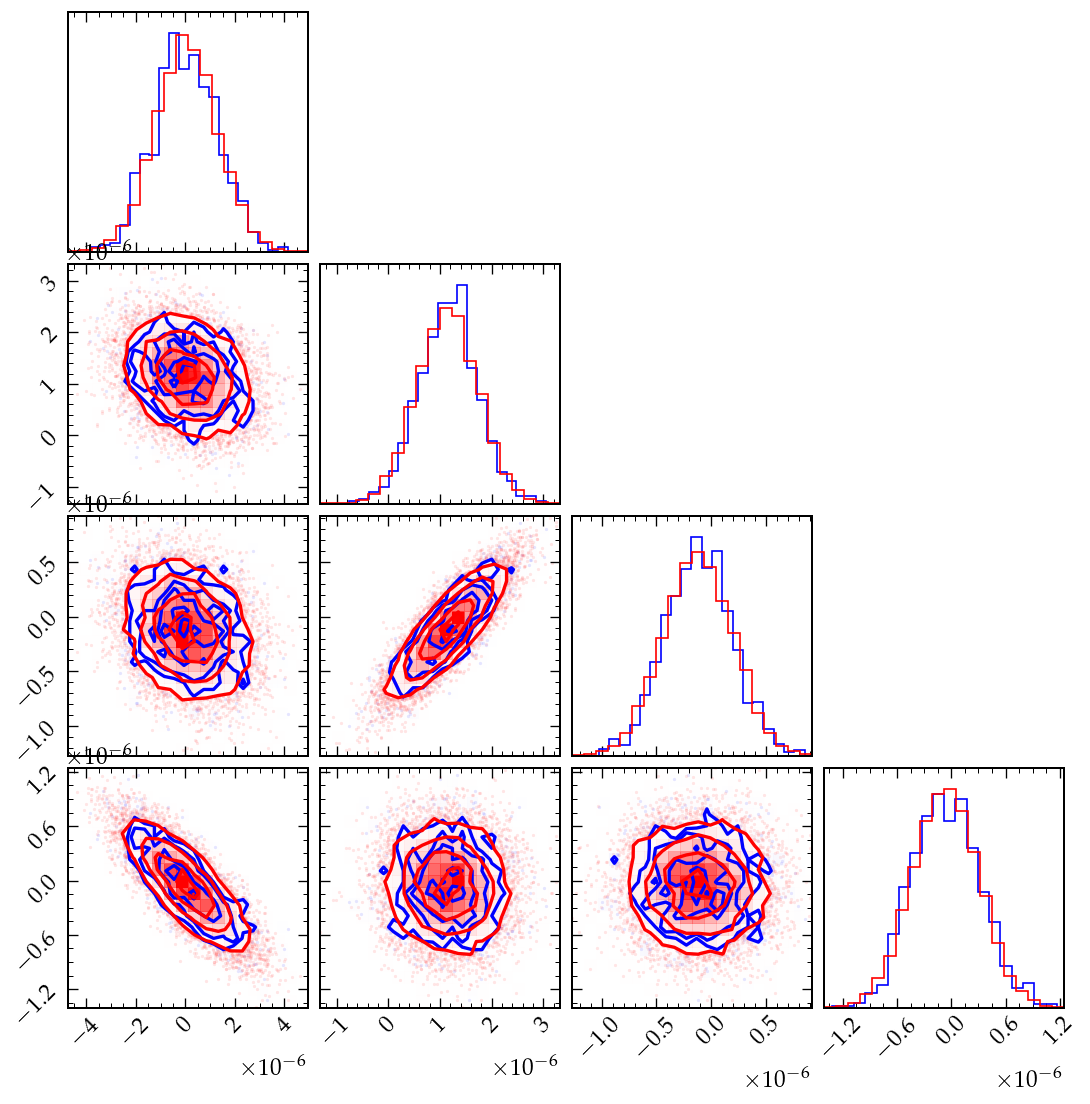

In [93]:
# sampled a's
fig = corner.corner(np.array(a_samples)[:, :4], 
                    color = 'blue', 
                    hist_kwargs = {'density':True})

# flow-constructed a's
corner.corner(np.array(a_flow_samples)[:, :4], 
              color = 'red', 
              hist_kwargs = {'density':True}, fig = fig)
plt.show()

In [94]:
plt.style.use("matplotlib.mplstyle")

204 of 26684 TOAs flagged as outliers


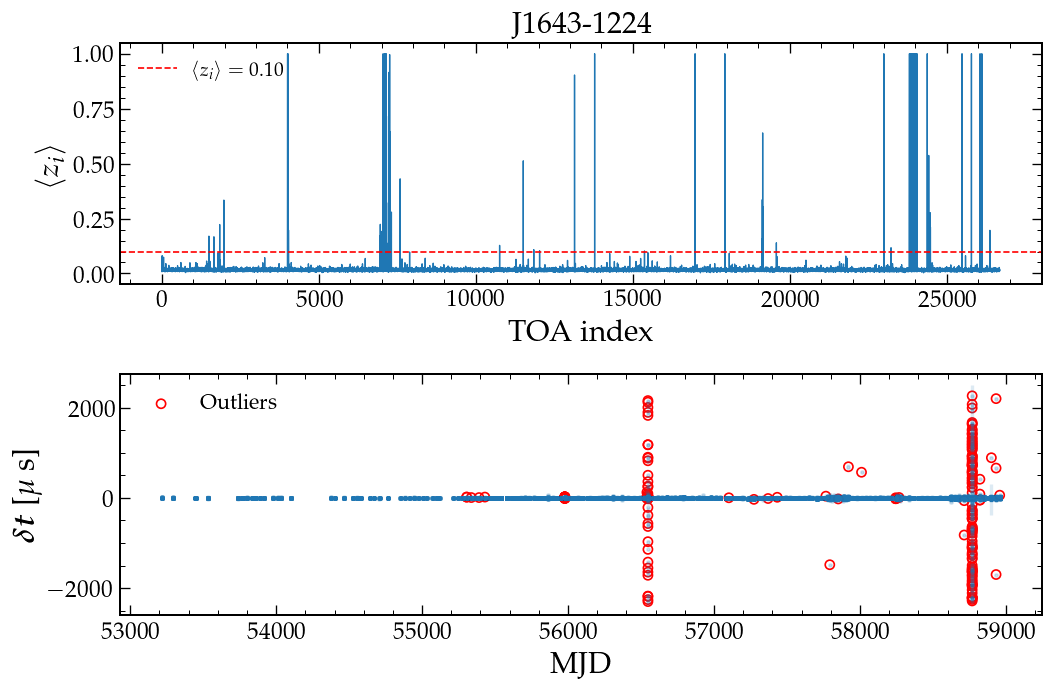

In [95]:
mask = np.mean(np.asarray(samples["z_i"]), axis=0) > 0.1
z_mean = np.mean(np.asarray(samples['z_i']), axis=0)
print(f'{mask.sum()} of {mask.size} TOAs flagged as outliers')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6))

ax1.plot(z_mean, lw=0.8)
ax1.axhline(0.1, c='r', ls='--', lw=1, label=r'$\langle z_i \rangle =0.10$')
ax1.set_xlabel('TOA index')
ax1.set_ylabel(r'$\langle z_i \rangle$')
ax1.set_title(f'{psr.name}')
ax1.legend(loc = 'upper left', fontsize = 11.8)

ax2.errorbar(psr.toas / 86400, psr.residuals/1e-6, yerr=psr.toaerrs/1e-6,
             alpha=0.15, fmt='o', markersize=2)
ax2.scatter(psr.toas[mask] / 86400, psr.residuals[mask]/1e-6,
            facecolor='none', edgecolor='r', s=30, label='Outliers')
ax2.set_xlabel('MJD')
ax2.set_ylabel(r'$\boldsymbol{\delta t}$ [$\mu$ s]')
ax2.legend()

plt.tight_layout()
plt.show()

In [96]:
samples = run_step2_SPNA_flow_corrected([flow_psr],[psr], ds.partial(phi_SPNA, powerlaw= ds.powerlaw), priordict_standard,
                    n_warmup=1024, n_samples=4096)

[1/1] Running step 2 SPNA flow-corrected for J1643-1224


sample: 100%|██████████| 5120/5120 [05:19<00:00, 16.02it/s, 23 steps of size 4.30e-01. acc. prob=0.88] 


In [97]:
m_ds = ds.ArrayLikelihood([ds.PulsarLikelihood([psr.residuals,
                            ds.makegp_timing(psr, svd=True, variable = True),
                            ds.makenoise_measurement(psr, noisedict=psr.noisedict, ecorr=ecorr),
                             ds.makegp_fourier(psr, powerlaw, rn_components, name='red_noise', T=ds.getspan(psr))]) for psr in [psr]])
                          

In [98]:
def create_rn_keys(psrnames):
    rn_amp_keys = [f"{psr_name}_red_noise_log10_A" for psr_name in psrnames]
    rn_gamma_keys = [f"{psr_name}_red_noise_gamma" for psr_name in psrnames]
    return rn_amp_keys, rn_gamma_keys

rn_amp_keys, rn_gamma_keys = create_rn_keys([s.name for s in [flow_psr]])

In [99]:
def log_prior(rho):
    log10As = jnp.array([rho[k] for k in rn_amp_keys])# + [rho[crn_log10A_key]])
    gammas  = jnp.array([rho[k] for k in rn_gamma_keys])# + [rho[crn_gamma_key]])

    ok = jnp.all((log10As >= -20) & (log10As <= -11)) & jnp.all((gammas >= 0) & (gammas <= 7))
    log_prior_val = jnp.where(ok, 0.0, -jnp.inf)
    return log_prior_val

def potential_ds(rho):
        lp = log_prior(rho)
        return - m_ds.logL(rho) - lp
    
kernel_ds = infer.NUTS(potential_fn=potential_ds)
sampler_ds = infer.MCMC(kernel_ds, num_warmup=1024, num_samples=4096, num_chains=1, progress_bar=True)

init_params_ds = {**{k: eta0_regularizer[i]['log10_A'] for i, k in enumerate(rn_amp_keys)},
                **{k: eta0_regularizer[i]['gamma']  for i, k in enumerate(rn_gamma_keys)}}

sampler_ds.run(jax.random.key(1), init_params=init_params_ds)

samples_ds = sampler_ds.get_samples()
sampler_ds.print_summary()



sample: 100%|██████████| 5120/5120 [03:46<00:00, 22.62it/s, 5 steps of size 7.17e-01. acc. prob=0.91]   



                                    mean       std    median      5.0%     95.0%     n_eff     r_hat
    J1643-1224_red_noise_gamma      0.75      0.32      0.75      0.20      1.25   2328.79      1.00
  J1643-1224_red_noise_log10_A    -12.16      0.05    -12.17    -12.24    -12.07   1926.41      1.00

Number of divergences: 230


In [100]:
samples = samples[psr.name]

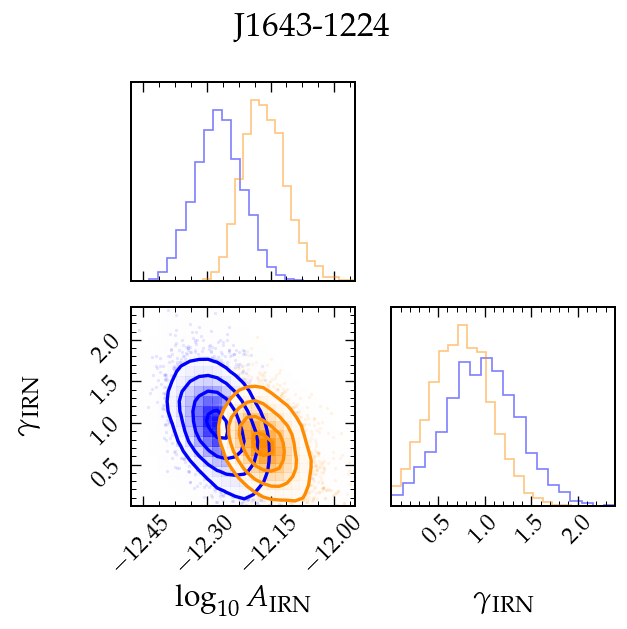

In [101]:
labels = [r"$\log_{10} A_\mathrm{IRN}$", r"$\gamma_\mathrm{IRN}$"]
labels_init = rn_amp_keys + rn_gamma_keys

# rename dict keys to the math-mode labels
irn_samples_flow = {labels[i]: samples[k] for i, k in enumerate(labels_init)}
irn_samples_ds   = {labels[i]: samples_ds[k]   for i, k in enumerate(labels_init)}

figure = corner.corner(irn_samples_flow,
                       hist_kwargs={"density": True, "alpha": 0.5, "color": "blue"},
                       color='blue',
                       show_titles=False,
                       smooth = True)

corner.corner(irn_samples_ds,
              hist_kwargs={"density": True, "alpha": 0.5, "color": "darkorange"},
              color='darkorange',
              fig=figure,
              show_titles=False,
              labelpad = 0.1,
              smooth = True)

figure.suptitle(psr.name, fontsize = 20)
plt.tight_layout()
plt.show()

### New psr object with outliers removed

In [102]:
import copy

psr_cleaned = copy.deepcopy(psr)
N_toas = mask.size

for attr, val in vars(psr).items():
    
    # if array and first entry contains old toa shape, replace with masked TOAs
    if isinstance(val, np.ndarray) and val.shape[0] == N_toas:
        setattr(psr_cleaned, attr, val[~mask])
    
    # if dict, loop over quantities inside dict and replace accordingly
    elif isinstance(val, dict):
        new_dict = {}
        for k, v in val.items():
            if isinstance(v, np.ndarray) and v.shape[0] == N_toas:
                new_dict[k] = v[~mask]
            else:
                new_dict[k] = v
        setattr(psr_cleaned, attr, new_dict)

In [103]:
# new likelihood obj. with residuals cleaned
psl_cleaned = ds.ArrayLikelihood([ds.PulsarLikelihood([
    psr_cleaned.residuals,
    ds.makegp_timing(psr_cleaned, svd=True, variable=True),
    ds.makenoise_measurement(psr_cleaned, noisedict=psr_cleaned.noisedict, ecorr=True),
    ds.makegp_fourier(psr_cleaned, powerlaw, rn_components, 
                      name='red_noise', T=ds.getspan(psr))])])

def potential_ds(rho):
    lp = log_prior(rho)
    return -psl_cleaned.logL(rho) - lp

kernel_ds = infer.NUTS(potential_fn=potential_ds)
sampler_ds_outlier_removed = infer.MCMC(kernel_ds, num_warmup=1024,
                                         num_samples=4096, progress_bar=True)
sampler_ds_outlier_removed.run(jax.random.key(1), init_params=init_params_ds)

sample: 100%|██████████| 5120/5120 [01:45<00:00, 48.42it/s, 3 steps of size 7.02e-01. acc. prob=0.92] 


In [104]:
irn_samples_ds_outliers_rem = sampler_ds_outlier_removed.get_samples()
samples_ds_outliers_rem  = {labels[i]: irn_samples_ds_outliers_rem[k]   for i, k in enumerate(labels_init)}

In [140]:
import pandas as pd
fifteen = pd.read_feather(r"J1643-1224_samples.feather")

dictfifteen = {
    rn_amp_keys[0]: fifteen[rn_amp_keys[0]].values,
    rn_gamma_keys[0]: fifteen[rn_gamma_keys[0]].values}

fifteensamples = np.column_stack([dictfifteen[rn_amp_keys[0]], dictfifteen[ rn_gamma_keys[0]]])

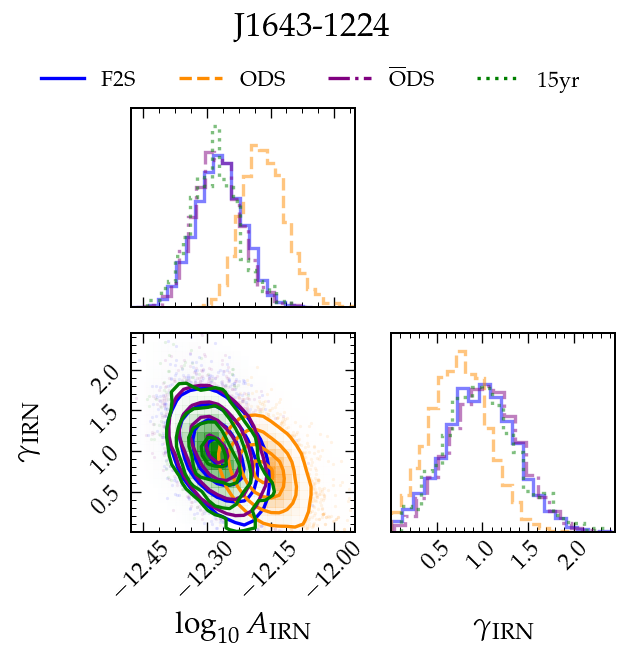

In [145]:
import matplotlib.lines as mlines

figure = corner.corner(irn_samples_flow,
                       hist_kwargs={"density": True, "alpha": 0.5, "color": "blue",
                                    "linestyle": "solid", "lw": 2},
                       color='blue',
                       show_titles=False,
                       smooth = True,
                       label = "F2S")

corner.corner(irn_samples_ds,
              hist_kwargs={"density": True, "alpha": 0.5, "color": "darkorange",
                           "linestyle": "dashed", "lw": 2},
              color='darkorange',
              fig=figure,
              show_titles=False,
              labelpad = 0.1,
              smooth = True,
              label = "O-DS")


corner.corner(samples_ds_outliers_rem,
              hist_kwargs={"density": True, "alpha": 0.5, "color": "purple",
                           "linestyle": "dashdot", "lw": 2},
              color='purple',
              fig=figure,
              show_titles=False,
              labelpad = 0.1,
              smooth = True,
              label = r"$\mathrm{\overline{O}-DS}$")

corner.corner(fifteensamples,
            hist_kwargs={"density": True, "alpha": 0.5, "color": "green",
                           "linestyle": "dotted", "lw": 2},
              color='green',
              fig=figure,
              show_titles=False,
              labelpad = 0.1,
              smooth = True,
              label = "15yr")
              
legend_handles = [mlines.Line2D([], [], color='blue', linestyle='solid',    linewidth=2, label='F2S'),
    mlines.Line2D([], [], color='darkorange', linestyle='dashed',   linewidth=2, label='ODS'),
    mlines.Line2D([], [], color='purple', linestyle='dashdot',  linewidth=2, label=r'$\mathrm{\overline{O}DS}$'),
     mlines.Line2D([], [], color='green', linestyle='dotted',  linewidth=2, label='15yr')]

figure.legend(handles=legend_handles, 
              loc='upper center',
              ncol = 4,
              bbox_to_anchor = (0.5, 0.96))

figure.suptitle(psr.name, fontsize = 20, y = 1.02)
plt.tight_layout()
plt.show()